In [8]:
using Plots

In [12]:
mutable struct SIMPLE
    # grid parameters
    X_grid::Int
    Y_grid::Int
    size_X::Float64
    size_Y::Float64
    dx::Float64
    dy::Float64

    step_counter::Int
    dv_max::Float64

    # physical parameter
    viscosity_coef::Float64

    # hyper parameters
    cell_reynolds::Float64
    sor_acceleration_rate::Float64
    sor_convergence_criterion::Float64
    max_iter::Int
    pressure_relaxation_rate::Float64
    velocity_relaxation_rate::Float64
    total_convergence_criterion::Float64

    # value of cells
    velocity_x
    velocity_y
    velocity_x_old
    velocity_y_old
    pressure
    pressure_correction

    # coefficients of discrete equation
    _ae
    _aw
    _an
    _as
    _ap
    _b

    _avx
    _avy

    # boundary condition
    velocity_of_upper_boundary::Float64

    function SIMPLE(X_grid, Y_grid, cell_reynolds; size_X=1.0, size_Y=1.0, velocity_of_upper_boundary=1.0, sor_acceleration_rate=1.8, sor_convergence_criterion=0.000001, max_iter=1000000, pressure_relaxation_rate=0.8, velocity_relaxation_rate=0.5, total_convergence_criterion=0.00001)
        dx = size_X / X_grid
        dy = size_Y / Y_grid
        viscosity_coef = 1.0 / cell_reynolds
        step_counter = 0
        dv_max = Inf64

        velocity_x = zeros(X_grid+2, Y_grid+2)
        velocity_y = zeros(X_grid+2, Y_grid+2)
        velocity_x_old = zeros(X_grid+2, Y_grid+2)
        velocity_y_old = zeros(X_grid+2, Y_grid+2)
        pressure = zeros(X_grid+2, Y_grid+2)
        pressure_correction = zeros(X_grid+2, Y_grid+2)

        _ae = zeros(X_grid+2, Y_grid+2)
        _aw = zeros(X_grid+2, Y_grid+2)
        _an = zeros(X_grid+2, Y_grid+2)
        _as = zeros(X_grid+2, Y_grid+2)
        _ap = zeros(X_grid+2, Y_grid+2)
        _b = zeros(X_grid+2, Y_grid+2)
        _avx = zeros(X_grid+2, Y_grid+2)
        _avy = zeros(X_grid+2, Y_grid+2)

        new(X_grid, Y_grid, size_X, size_Y, dx, dy, step_counter, dv_max, viscosity_coef,
            cell_reynolds, sor_acceleration_rate, sor_convergence_criterion, max_iter, pressure_relaxation_rate, velocity_relaxation_rate, total_convergence_criterion,
            velocity_x, velocity_y, velocity_x_old, velocity_y_old, pressure, pressure_correction,
            _ae, _aw, _an, _as, _ap, _b, _avx, _avy, velocity_of_upper_boundary)
    end
end

function show_settings(simple)
    println("<settings>")
    println("X_grid = $(simple.X_grid), Y_grid = $(simple.Y_grid)\n(X_size, Y_size) = ($(simple.size_X), $(simple.size_Y))\ndx = $(simple.dx), dy = $(simple.dy)")
    println("viscosity_coef = $(simple.viscosity_coef), reynolds number = $(simple.cell_reynolds)\nsor_acceleration_rate = $(simple.sor_acceleration_rate), sor_convergence_criterion = $(simple.sor_convergence_criterion)")
    println("pressure_relaxation_rate = $(simple.pressure_relaxation_rate), velocity_relaxation_rate = $(simple.velocity_relaxation_rate)\nmax_iter = $(simple.max_iter), total_convergence_criterion = $(simple.total_convergence_criterion)")
    println("velocity_of_upper_boundary = $(simple.velocity_of_upper_boundary)\n")
end

function solve!(simple, method="center")
    show_settings(simple)
    while simple.dv_max > simple.total_convergence_criterion
        simple.velocity_x_old = copy(simple.velocity_x)
        simple.velocity_y_old = copy(simple.velocity_y)
        velocity_x_update!(simple, method)
        velocity_y_update!(simple, method)
        pressure_update!(simple)
        correction!(simple)

        simple.step_counter += 1
        if simple.step_counter > simple.max_iter
            println("convergence is too late: at main loop: in step = $(smac.step_counter)")
            break
        elseif simple.step_counter % 100 == 0
            println("step = $(simple.step_counter), error = $(simple.dv_max) / $(simple.total_convergence_criterion)")
        end
    end
end

function _coefficients_setting!(simple, method, v_x_east, v_x_west, v_y_north, v_y_south, i, j)
    if method == "upwind"
        simple._aw[i, j] = (max(v_x_west, 0.0) + simple.viscosity_coef / simple.dx) * simple.dy
        simple._ae[i, j] = (max(-v_x_east, 0.0) + simple.viscosity_coef / simple.dx) * simple.dy
        simple._as[i, j] = (max(v_y_south, 0.0) + simple.viscosity_coef / simple.dy) * simple.dx
        simple._an[i, j] = (max(-v_y_north, 0.0) + simple.viscosity_coef / simple.dy) * simple.dx
    elseif method == "center"
        simple._aw[i, j] = (0.5 * v_x_west + simple.viscosity_coef / simple.dx) * simple.dy
        simple._ae[i, j] = (-0.5 * v_x_east + simple.viscosity_coef / simple.dx) * simple.dy
        simple._as[i, j] = (0.5 * v_y_south + simple.viscosity_coef / simple.dy) * simple.dx
        simple._an[i, j] = (-0.5 * v_y_north + simple.viscosity_coef / simple.dy) * simple.dx
    else
        error("invalid method type: in _coefficients_setting!")
    end
    simple._ap[i, j] = simple._aw[i, j] + simple._ae[i, j] + simple._as[i, j] + simple._an[i, j]
end

function velocity_x_update!(simple, method; iter_max=10)
    for i = 2 : simple.X_grid, j = 2 : simple.Y_grid + 1
        v_x_east = 0.5 * (simple.velocity_x[i, j] + simple.velocity_x[i+1, j])
        v_x_west = 0.5 * (simple.velocity_x[i, j] + simple.velocity_x[i-1, j])
        v_y_north = 0.5 * (simple.velocity_y[i, j] + simple.velocity_y[i+1, j])
        v_y_south = 0.5 * (simple.velocity_y[i, j-1] + simple.velocity_y[i+1, j-1])

        _coefficients_setting!(simple, method, v_x_east, v_x_west, v_y_north, v_y_south, i, j)

        simple._b[i, j] = (simple.pressure[i, j] - simple.pressure[i+1, j]) * simple.dy + (1.0 - simple.velocity_relaxation_rate) / simple.velocity_relaxation_rate * simple._ap[i, j] * simple.velocity_x_old[i, j]
        simple._ap[i, j] /= simple.velocity_relaxation_rate
        simple._avx[i, j] = simple._ap[i, j]

        # boundary condition
        if j == 2
            simple._ap[i, j] += simple._as[i, j]
            simple._as[i, j] = 0.0
        elseif j == simple.Y_grid + 1
            simple._ap[i, j] += simple._an[i, j]
            simple._b[i, j] += 2.0 * simple._an[i, j] * simple.velocity_of_upper_boundary
            simple._an[i, j] = 0.0
        end
    end

    # iterative calculation
    for _ = 1 : iter_max
        for i = 2 : simple.X_grid, j = 2 : simple.Y_grid + 1
            simple.velocity_x[i, j] = (simple._aw[i, j] * simple.velocity_x[i-1, j] + simple._ae[i, j] * simple.velocity_x[i+1, j] + simple._as[i, j] * simple.velocity_x[i, j-1] + simple._an[i, j] * simple.velocity_x[i, j+1] + simple._b[i, j]) / simple._ap[i, j]
        end
    end
end

function velocity_y_update!(simple, method; iter_max=10)
    for i = 2 : simple.X_grid + 1, j = 2 : simple.Y_grid
        v_x_east = 0.5 * (simple.velocity_x[i, j] + simple.velocity_x[i, j+1])
        v_x_west = 0.5 * (simple.velocity_x[i-1, j] + simple.velocity_x[i-1, j+1])
        v_y_north = 0.5 * (simple.velocity_y[i, j] + simple.velocity_y[i, j+1])
        v_y_south = 0.5 * (simple.velocity_y[i, j-1] + simple.velocity_y[i, j])

        _coefficients_setting!(simple, method, v_x_east, v_x_west, v_y_north, v_y_south, i, j)

        simple._b[i, j] = (simple.pressure[i, j] - simple.pressure[i, j+1]) * simple.dx + (1.0 - simple.velocity_relaxation_rate) / simple.velocity_relaxation_rate * simple._ap[i, j] * simple.velocity_y_old[i, j]
        simple._ap[i, j] /= simple.velocity_relaxation_rate
        simple._avy[i, j] = simple._ap[i, j]

        # boundary condition
        if i == 2
            simple._ap[i, j] += simple._aw[i, j]
            simple._aw[i, j] = 0.0
        elseif i == simple.X_grid + 1
            simple._ap[i, j] += simple._ae[i, j]
            simple._ae[i, j] = 0.0
        end
    end

    # iterative calculation
    for _ = 1 : iter_max
        for i = 2 : simple.X_grid + 1, j = 2 : simple.Y_grid
            simple.velocity_y[i, j] = (simple._aw[i, j] * simple.velocity_y[i-1, j] + simple._ae[i, j] * simple.velocity_y[i+1, j] + simple._as[i, j] * simple.velocity_y[i, j-1] + simple._an[i, j] * simple.velocity_y[i, j+1] + simple._b[i, j]) / simple._ap[i, j]
        end
    end
end

function pressure_update!(simple)
    for i = 2 : simple.X_grid + 1, j = 2 : simple.Y_grid + 1
        if i != 2
            simple._aw[i, j] = simple.dy ^ 2 / simple._avx[i-1, j]
        else
            simple._aw[i, j] = 0.0
        end

        if i != simple.X_grid + 1
            simple._ae[i, j] = simple.dy ^ 2 / simple._avx[i, j]
        else
            simple._ae[i, j] = 0.0
        end

        if j != 2
            simple._as[i, j] = simple.dx ^ 2 / simple._avy[i, j-1]
        else
            simple._as[i, j] = 0.0
        end

        if j != simple.Y_grid + 1
            simple._an[i, j] = simple.dx ^ 2 / simple._avy[i, j]
        else
            simple._an[i, j] = 0.0
        end

        simple._ap[i, j] = simple._aw[i, j] + simple._ae[i, j] + simple._as[i, j] + simple._an[i, j]
        simple._b[i, j] = -(simple.velocity_x[i, j] - simple.velocity_x[i-1, j]) * simple.dy - (simple.velocity_y[i, j] - simple.velocity_y[i, j-1]) * simple.dx
    end

    _sor_pressure_correction!(simple)
end

function correction!(simple)
    dv_max = 0.0
    for i = 2 : simple.X_grid + 1, j = 2 : simple.Y_grid + 1
        if i <= simple.X_grid
            simple.velocity_x[i, j] += (simple.pressure_correction[i, j] - simple.pressure_correction[i+1, j]) * simple.dy / simple._avx[i, j]
        end
        if j <= simple.Y_grid
            simple.velocity_y[i, j] += (simple.pressure_correction[i, j] - simple.pressure_correction[i, j+1]) * simple.dx / simple._avy[i, j]
        end
        simple.pressure[i, j] += simple.pressure_correction[i, j] * simple.pressure_relaxation_rate
        dv_max = max(dv_max, abs(simple.velocity_y[i, j] - simple.velocity_y_old[i, j]))
    end
    simple.dv_max = dv_max
end

function _sor_pressure_correction!(simple)
    iter = 0
    err = Inf64
    while err > simple.sor_convergence_criterion
        iter += 1
        err = 0.0
        for i = 2 : simple.X_grid + 1, j = 2 : simple.Y_grid + 1
            pressure_correction_new = (simple._aw[i, j] * simple.pressure_correction[i-1, j] + simple._ae[i, j] * simple.pressure_correction[i+1, j] + simple._as[i, j] * simple.pressure_correction[i, j-1] + simple._an[i, j] * simple.pressure_correction[i, j+1] + simple._b[i, j]) / simple._ap[i, j]
            err = max(err, abs(pressure_correction_new - simple.pressure_correction[i, j]))
            simple.pressure_correction[i, j] += simple.sor_acceleration_rate * (pressure_correction_new - simple.pressure_correction[i, j])
        end

        if iter % 10000 == 0
            println("iter = $(iter), error = $(err)")
        elseif iter > 1000000
            println("convergence is too late: at SOR method: in step = $(simple.step_counter)")
            break
        end
    end
end

function plot_velocity(simple; decimation=1, scale=2.0)
    x = []
    y = []
    velocity_x = []
    velocity_y = []
    _scale = simple.dx * decimation * scale / simple.velocity_of_upper_boundary
    for i = 2 : decimation : simple.X_grid + 1
        for j = 2 : decimation : simple.Y_grid + 1
            v_x_center = 0.5 * (simple.velocity_x[i, j] + simple.velocity_x[i-1, j])
            v_y_center = 0.5 * (simple.velocity_y[i, j] + simple.velocity_y[i, j-1])
            push!(x, (i - 1.5) * simple.dx)
            push!(y, (j - 1.5) * simple.dy)
            push!(velocity_x, v_x_center * _scale)
            push!(velocity_y, v_y_center * _scale)
        end
    end

    quiver(x, y, quiver=(velocity_x, velocity_y))
end

function plot_pressure(simple)
    x = [(i - 1.5) * simple.dx for i = 2 : simple.X_grid + 1]
    y = [(j - 1.5) * simple.dx for j = 2 : simple.Y_grid + 1]
    p = simple.pressure[2 : simple.X_grid + 1, 2 : simple.Y_grid + 1]

    contour(x, y, transpose(p))
end

function plot_streamline(simple)
    flow = zeros(simple.X_grid + 1, simple.Y_grid + 1)
    for i = 1 : simple.X_grid + 1
        for j = 2 : simple.Y_grid
            flow[i, j] = flow[i, j-1] + simple.velocity_x[i, j] * simple.dx
        end
    end

    x = [(i - 1) * simple.dx for i = 1 : simple.X_grid + 1]
    y = [(j - 1) * simple.dy for j = 1 : simple.Y_grid + 1]
    contour(x, y, transpose(flow))
end

function plot_v_x_on_halfline(simple)
    half = div(simple.Y_grid, 2) + 1
    y = [(j - 2) * simple.dy for j = 2 : simple.Y_grid + 1]
    u = [simple.velocity_x[half, j] for j = 2 : simple.Y_grid + 1]
    plot(y, u, permute=(:y, :x))
end

plot_v_x_on_halfline (generic function with 1 method)

In [10]:
X_grid = 20
Y_grid = 20
Reynolds = 100.0

100.0

In [13]:
simple = SIMPLE(X_grid, Y_grid, Reynolds)
solve!(simple)

<settings>
X_grid = 20, Y_grid = 20
(X_size, Y_size) = (1.0, 1.0)
dx = 0.05, dy = 0.05
viscosity_coef = 0.01, reynolds number = 100.0
sor_acceleration_rate = 1.8, sor_convergence_criterion = 1.0e-6
pressure_relaxation_rate = 0.8, velocity_relaxation_rate = 0.5
max_iter = 1000000, total_convergence_criterion = 1.0e-5
velocity_of_upper_boundary = 1.0

step = 100, error = 0.00031471505018518253 / 1.0e-5
step = 200, error = 1.2793932951532527e-5 / 1.0e-5


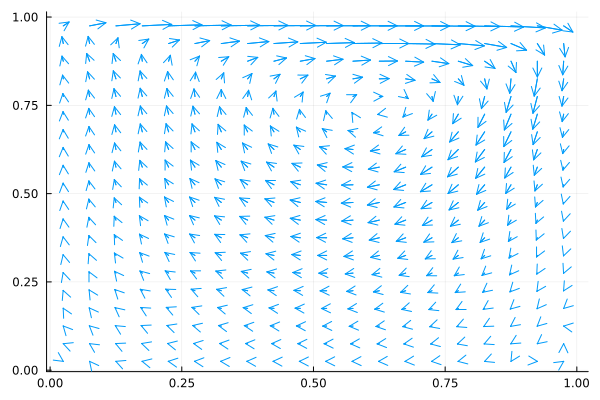

In [15]:
plot_velocity(simple)

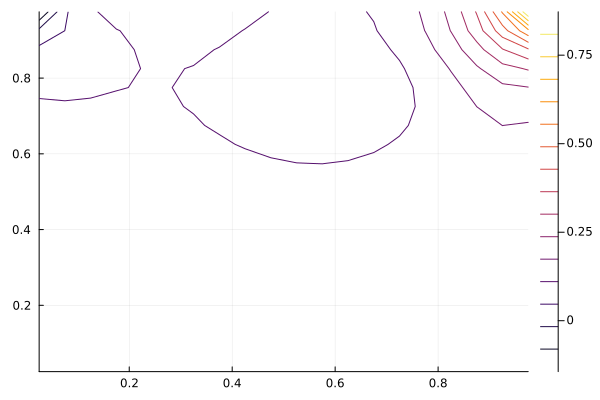

In [16]:
plot_pressure(simple)

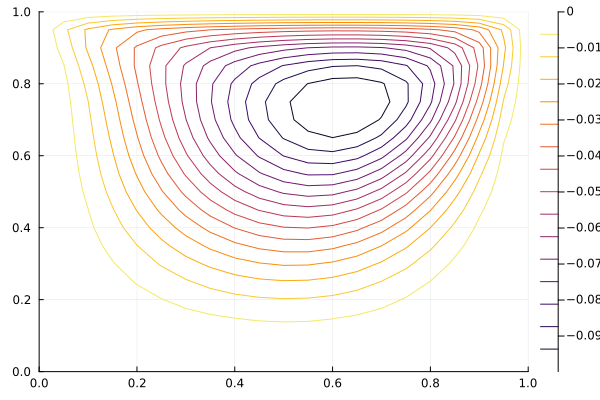

In [17]:
plot_streamline(simple)

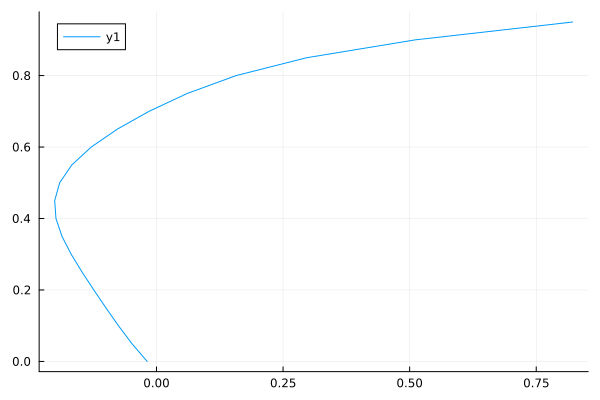

In [18]:
plot_v_x_on_halfline(simple)